# Customer Intent Intelligence
## Notebook 03 — Semantic Models

### Objective

Convert customer queries into dense semantic embeddings using a pretrained
Sentence Transformer and evaluate different classifiers:

1. Logistic Regression
2. Linear SVM
3. Multi-Layer Perceptron (MLP)

The best semantic model will be compared against the TF-IDF baselines.

## 1.Imports

In [1]:
# Dependencies for this notebook (already listed in requirements.txt):
#
# !pip install sentence-transformers scikit-learn pandas matplotlib joblib

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

## 2.Load processed Data

In [3]:
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (10003, 3)
Test shape: (3080, 3)


## 3.Define feartures and target

In [4]:
X_train = train_df["processed_text"]
y_train = train_df["category"]

X_test = test_df["processed_text"]
y_test = test_df["category"]

## 4. Load sentence trasnformer

In [5]:
embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

## 5.Generate Embedding

In [6]:
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

In [7]:
print("Training embeddings:", X_train_embeddings.shape)
print("Testing embeddings:", X_test_embeddings.shape)

Training embeddings: (10003, 384)
Testing embeddings: (3080, 384)


In [8]:
os.makedirs(
    "../data/processed/embeddings",
    exist_ok=True
)

np.save(
    "../data/processed/embeddings/train_embeddings.npy",
    X_train_embeddings
)

np.save(
    "../data/processed/embeddings/test_embeddings.npy",
    X_test_embeddings
)

## 5b. Validation split\n\nModel selection needs a held-out set that is not the test set.\n\nThe training embeddings are split into a sub-training set and a\nvalidation set. Each classifier is fitted on the sub-training set and\nscored on the validation set, and that validation score is what selects\nthe final model.\n\nEach classifier is then refitted on the full training set and evaluated\nonce on the test set, which is reported but never used for selection.

In [9]:
(
    X_tr_embeddings,
    X_val_embeddings,
    y_tr,
    y_val
) = train_test_split(
    X_train_embeddings,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Sub-training embeddings:", X_tr_embeddings.shape)
print("Validation embeddings:", X_val_embeddings.shape)
print("Test embeddings:", X_test_embeddings.shape)

Sub-training embeddings: (8002, 384)
Validation embeddings: (2001, 384)
Test embeddings: (3080, 384)


## 6.Evaluation Function

In [10]:
def evaluate_model(y_true, y_pred, model_name):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

## 7.Logistic Regression

In [11]:
# Validation fit: used only for model selection.
lr_val_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

lr_val_model.fit(
    X_tr_embeddings,
    y_tr
)

lr_val_f1 = f1_score(
    y_val,
    lr_val_model.predict(X_val_embeddings),
    average="macro",
    zero_division=0
)

print("Validation Macro F1:", round(lr_val_f1, 4))

Validation Macro F1: 0.9028


In [12]:
# Final fit on the full training set, evaluated once on the held-out test set.
lr_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    random_state=42
)

lr_model.fit(
    X_train_embeddings,
    y_train
)

lr_pred = lr_model.predict(
    X_test_embeddings
)

In [13]:
lr_results = evaluate_model(
    y_test,
    lr_pred,
    "Embeddings + Logistic Regression"
)

lr_results

{'Model': 'Embeddings + Logistic Regression',
 'Accuracy': 0.9081168831168831,
 'Macro Precision': 0.9126817266016494,
 'Macro Recall': 0.9081168831168831,
 'Macro F1': 0.9079477557401493,
 'Weighted F1': 0.9079477557401492}

## 8.Linear SVM

In [14]:
# Validation fit: used only for model selection.
svm_val_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_val_model.fit(
    X_tr_embeddings,
    y_tr
)

svm_val_f1 = f1_score(
    y_val,
    svm_val_model.predict(X_val_embeddings),
    average="macro",
    zero_division=0
)

print("Validation Macro F1:", round(svm_val_f1, 4))

Validation Macro F1: 0.9261


In [15]:
# Final fit on the full training set, evaluated once on the held-out test set.
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train_embeddings,
    y_train
)

svm_pred = svm_model.predict(
    X_test_embeddings
)

In [16]:
svm_results = evaluate_model(
    y_test,
    svm_pred,
    "Embeddings + Linear SVM"
)

svm_results

{'Model': 'Embeddings + Linear SVM',
 'Accuracy': 0.9275974025974026,
 'Macro Precision': 0.9298762670280931,
 'Macro Recall': 0.9275974025974028,
 'Macro F1': 0.9273309532075863,
 'Weighted F1': 0.9273309532075865}

## 11 MLP

In [17]:
def build_mlp():

    return MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=50,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        random_state=42
    )


mlp_model = build_mlp()

mlp_model

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",64
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"n_iter_no_change n_iter_no_change: int, default=10Maximum number of epochs to not meet ``tol`` improvement.Only effective when solver='sgd' or 'adam'... versionadded:: 0.20",5
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.O

In [18]:
# Validation fit: used only for model selection.
mlp_val_model = build_mlp()

mlp_val_model.fit(
    X_tr_embeddings,
    y_tr
)

mlp_val_f1 = f1_score(
    y_val,
    mlp_val_model.predict(X_val_embeddings),
    average="macro",
    zero_division=0
)

print("Validation Macro F1:", round(mlp_val_f1, 4))

Validation Macro F1: 0.893


In [19]:
# Final fit on the full training set, evaluated once on the held-out test set.
mlp_model = build_mlp()

mlp_model.fit(
    X_train_embeddings,
    y_train
)

mlp_pred = mlp_model.predict(
    X_test_embeddings
)

In [20]:
mlp_results = evaluate_model(
    y_test,
    mlp_pred,
    "Embeddings + MLP"
)

mlp_results

{'Model': 'Embeddings + MLP',
 'Accuracy': 0.9068181818181819,
 'Macro Precision': 0.9135196952886842,
 'Macro Recall': 0.9068181818181816,
 'Macro F1': 0.9073111592197447,
 'Weighted F1': 0.9073111592197447}

## 12. Evaluation

In [21]:
semantic_results = pd.DataFrame([
    lr_results,
    svm_results,
    mlp_results
])

# Validation Macro F1 is the model-selection metric; the test columns are
# reported once, after selection.
semantic_results.insert(
    1,
    "Validation Macro F1",
    [
        lr_val_f1,
        svm_val_f1,
        mlp_val_f1
    ]
)

semantic_results.round(4)

,Model,Validation Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Embeddings + Logistic Regression,0.9028,0.9081,0.9127,0.9081,0.9079,0.9079
1,Embeddings + Linear SVM,0.9261,0.9276,0.9299,0.9276,0.9273,0.9273
2,Embeddings + MLP,0.8930,0.9068,0.9135,0.9068,0.9073,0.9073


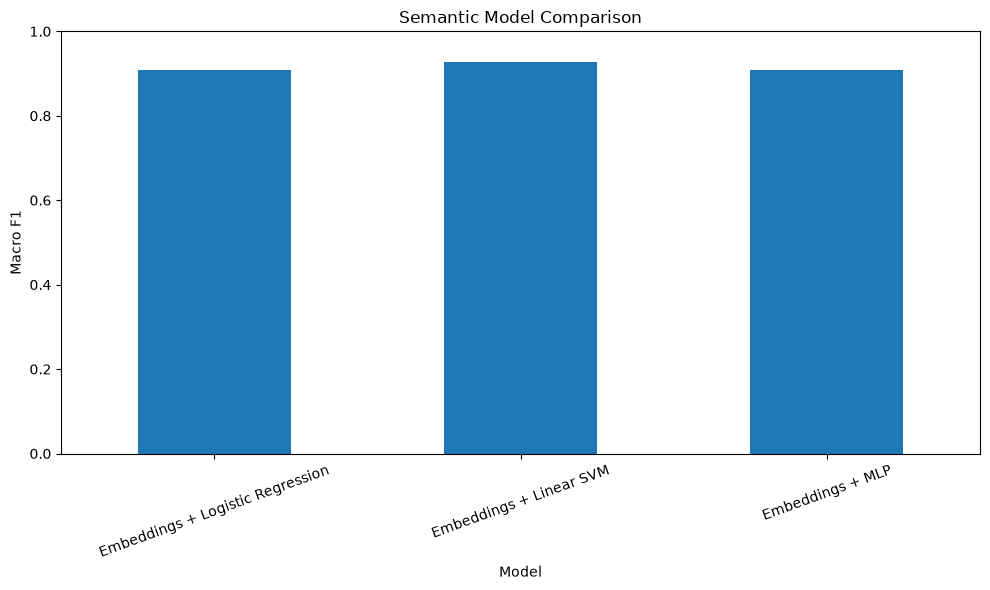

In [22]:
semantic_results.plot(
    x="Model",
    y="Macro F1",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("Semantic Model Comparison")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

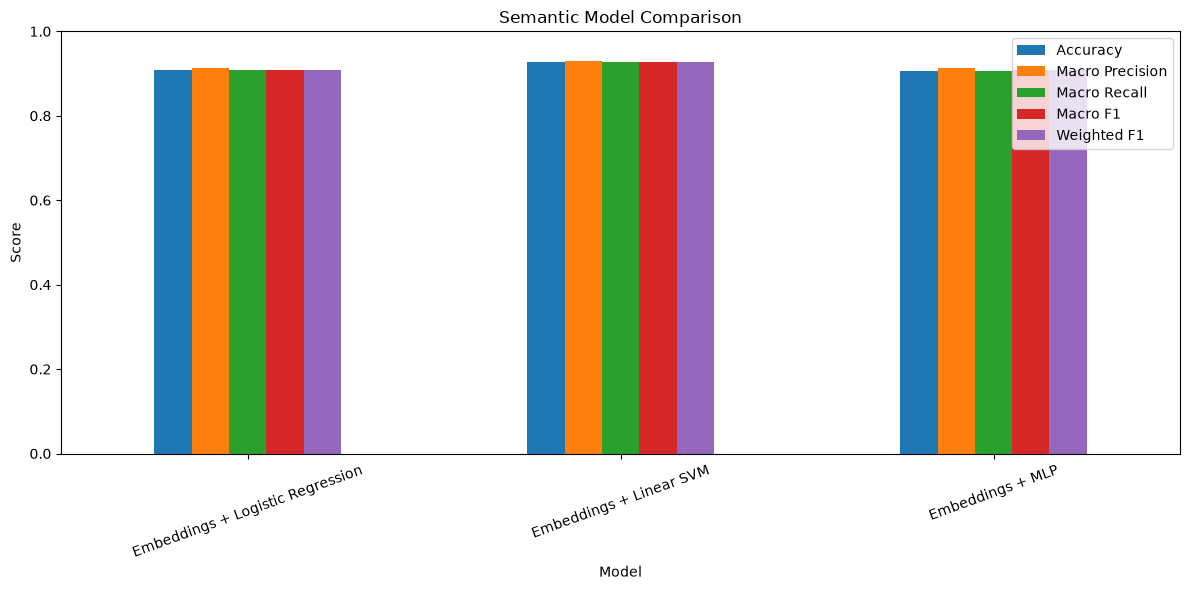

In [23]:
metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1"
]

semantic_plot = semantic_results.set_index(
    "Model"
)[metrics]

semantic_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Semantic Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [24]:
best_model_name = semantic_results.loc[
    semantic_results["Validation Macro F1"].idxmax(),
    "Model"
]

print("Best semantic model (selected on validation):")
print(best_model_name)

Best semantic model (selected on validation):
Embeddings + Linear SVM


In [25]:
baseline_results = pd.read_csv(
    "../reports/results/baseline_results.csv"
)

baseline_results.round(4)

,Model,Validation Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.8735,0.8912,0.8958,0.8912,0.8915,0.8915
1,TF-IDF + Linear SVM,0.8820,0.8906,0.8944,0.8906,0.8906,0.8906


In [26]:
all_model_results = pd.concat(
    [
        baseline_results,
        semantic_results
    ],
    ignore_index=True
)

all_model_results.round(4)

,Model,Validation Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression,0.8735,0.8912,0.8958,0.8912,0.8915,0.8915
1,TF-IDF + Linear SVM,0.8820,0.8906,0.8944,0.8906,0.8906,0.8906
2,Embeddings + Logistic Regression,0.9028,0.9081,0.9127,0.9081,0.9079,0.9079
3,Embeddings + Linear SVM,0.9261,0.9276,0.9299,0.9276,0.9273,0.9273
4,Embeddings + MLP,0.8930,0.9068,0.9135,0.9068,0.9073,0.9073


##  13.Overall comparison

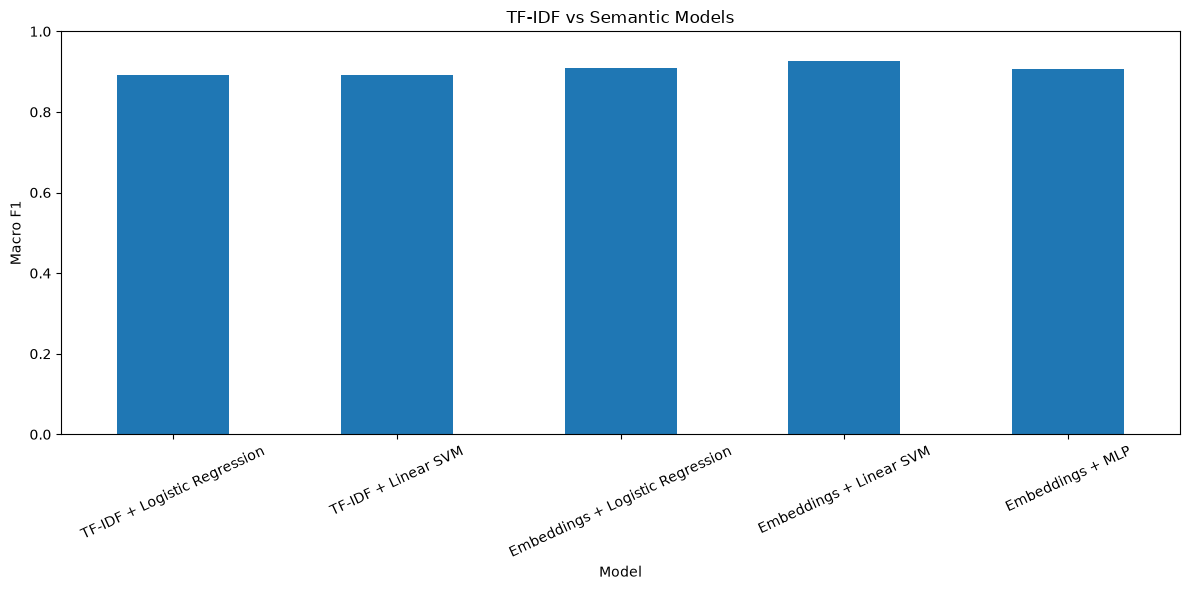

In [27]:
all_model_results.plot(
    x="Model",
    y="Macro F1",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("TF-IDF vs Semantic Models")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

## 14. Per-intent perfromance

In [28]:
lr_report = classification_report(
    y_test,
    lr_pred,
    output_dict=True,
    zero_division=0
)

svm_report = classification_report(
    y_test,
    svm_pred,
    output_dict=True,
    zero_division=0
)

mlp_report = classification_report(
    y_test,
    mlp_pred,
    output_dict=True,
    zero_division=0
)

In [29]:
labels = sorted(
    y_train.unique()
)

intent_comparison = pd.DataFrame({
    "Intent": labels,

    "Semantic LR F1": [
        lr_report[intent]["f1-score"]
        for intent in labels
    ],

    "Semantic SVM F1": [
        svm_report[intent]["f1-score"]
        for intent in labels
    ],

    "MLP F1": [
        mlp_report[intent]["f1-score"]
        for intent in labels
    ]
})

## 15. Intents where MLP performs poorly

In [30]:
intent_comparison.sort_values(
    "MLP F1"
).head(10)

,Intent,Semantic LR F1,Semantic SVM F1,MLP F1
23,compromised_card,0.826667,0.860759,0.761905
21,cash_withdrawal_not_recognised,0.800000,0.917647,0.762887
66,transfer_not_received_by_recipient,0.829268,0.825000,0.769231
35,extra_charge_on_statement,0.829268,0.829268,0.794872
28,declined_transfer,0.811594,0.857143,0.800000
62,topping_up_by_card,0.825000,0.875000,0.800000
6,balance_not_updated_after_bank_transfer,0.756098,0.784810,0.805556
49,pending_transfer,0.764706,0.849315,0.811594
12,card_arrival,0.850000,0.853333,0.840909
17,card_payment_not_recognised,0.789474,0.810811,0.842105


In [31]:
intent_comparison.sort_values(
    "MLP F1",
    ascending=False
).head(10)

,Intent,Semantic LR F1,Semantic SVM F1,MLP F1
70,verify_source_of_funds,1.000000,0.987654,1.000000
71,verify_top_up,1.000000,1.000000,1.000000
45,passcode_forgotten,1.000000,1.000000,0.987654
2,age_limit,0.987654,0.987654,0.987654
4,atm_support,0.962025,0.975000,0.987654
63,transaction_charged_twice,0.975610,0.963855,0.987654
31,edit_personal_details,1.000000,0.987654,0.987654
10,card_about_to_expire,0.962963,0.975610,0.987342
3,apple_pay_or_google_pay,0.987654,0.987654,0.987342
55,terminate_account,0.963855,0.987654,0.975610


## 16. Save best model

In [32]:
best_row = semantic_results.loc[
    semantic_results["Validation Macro F1"].idxmax()
]

best_row

Model                  Embeddings + Linear SVM
Validation Macro F1                   0.926058
Accuracy                              0.927597
Macro Precision                       0.929876
Macro Recall                          0.927597
Macro F1                              0.927331
Weighted F1                           0.927331
Name: 1, dtype: object

In [33]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    lr_model,
    "../models/semantic_logistic_regression.pkl"
)

joblib.dump(
    svm_model,
    "../models/semantic_svm.pkl"
)

joblib.dump(
    mlp_model,
    "../models/semantic_mlp.pkl"
)

['../models/semantic_mlp.pkl']

## 17. Save results

In [34]:
os.makedirs(
    "../reports/results",
    exist_ok=True
)

semantic_results.to_csv(
    "../reports/results/semantic_results.csv",
    index=False
)

all_model_results.to_csv(
    "../reports/results/all_model_results.csv",
    index=False
)

intent_comparison.to_csv(
    "../reports/results/semantic_intent_comparison.csv",
    index=False
)

## 18. Save predictions

In [35]:
semantic_predictions = test_df[
    ["text", "category"]
].copy()

semantic_predictions["lr_prediction"] = lr_pred
semantic_predictions["svm_prediction"] = svm_pred
semantic_predictions["mlp_prediction"] = mlp_pred

In [36]:
semantic_predictions["lr_correct"] = (
    semantic_predictions["category"]
    == semantic_predictions["lr_prediction"]
)

semantic_predictions["svm_correct"] = (
    semantic_predictions["category"]
    == semantic_predictions["svm_prediction"]
)

semantic_predictions["mlp_correct"] = (
    semantic_predictions["category"]
    == semantic_predictions["mlp_prediction"]
)

In [37]:
semantic_predictions.to_csv(
    "../reports/results/semantic_predictions.csv",
    index=False
)

# Conclusion

Sentence Transformer embeddings were used to create dense semantic
representations of BANKING77 customer queries.

Three classifiers were evaluated:

1. Logistic Regression
2. Linear SVM
3. Multi-Layer Perceptron

Macro F1 was used as the primary model-selection metric.

The semantic models were compared against the TF-IDF baselines from
Notebook 02.

The models, embeddings, predictions, and evaluation results were saved
for downstream error analysis.